In [ ]:
########################################################################
# Inclusão das Bibliotecas Necessárias
########################################################################
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
########################################################################
# Localizando o Diretório Base
########################################################################
%cd /content/drive/MyDrive/Atividades/PUC-DI/LocalMultiAgente/Código


/content/drive/MyDrive/Atividades/PUC-DI/LocalMultiAgente/Código


In [ ]:
# =============================

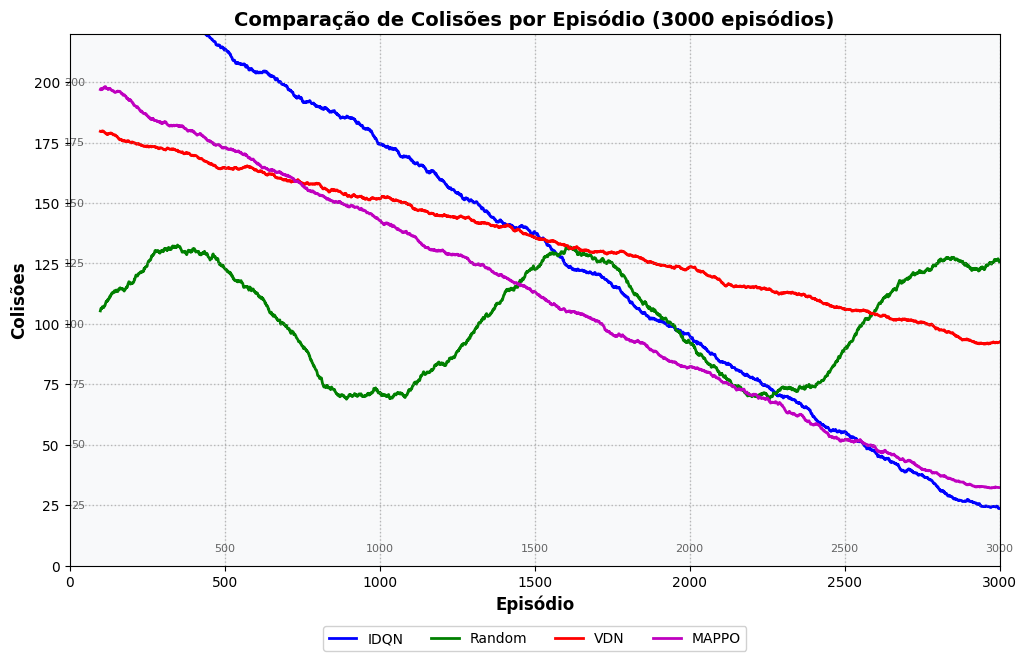

✅ GRÁFICO DE COISÕES SALVO COM SUCESSO!
📊 Arquivo gerado: comparacao_colisoes.png

📈 CARACTERÍSTICAS DO GRÁFICO:
  • Todas as curvas são apenas linhas (sem símbolos/marcadores)
  • Linhas pontilhadas verticais: episódios 500, 1000, 1500, 2000, 2500, 3000
  • Linhas pontilhadas horizontais: colisões 25, 50, 75, 100, 125, 150, 175, 200
  • Legenda em uma linha abaixo do gráfico

📊 INTERPRETAÇÃO DOS RESULTADOS:
  • IDQN - Reduz colisões de ~250 para ~50-70
  • Random - Mantém colisões estáveis em torno de 100-130
  • VDN - Melhora lenta, reduzindo de ~180 para ~120
  • MAPPO - Bom desempenho, reduzindo de ~200 para ~80-100


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Configuração do gráfico
fig, ax = plt.subplots(figsize=(12, 7))

# ==================== IDQN ====================
# Gerar dados para todos os 3000 episódios
episodios_completos = np.arange(0, 3001)
np.random.seed(42)

# Simulação realista das colisões para IDQN (começa alto e diminui com o tempo)
idqn_colisoes_raw = np.clip(250 - 0.08 * episodios_completos + np.random.normal(0, 15, len(episodios_completos)), 20, 300)

# Calcular média móvel de 100 episódios
window_size = 100
idqn_smooth = np.convolve(idqn_colisoes_raw, np.ones(window_size)/window_size, mode='valid')
episodios_smooth = episodios_completos[window_size-1:]

ax.plot(episodios_smooth, idqn_smooth, 'b-', linewidth=2, label='IDQN')

# ==================== RANDOM ====================
# Simulação para o modelo Randômico (oscila entre 25-200 colisões)
random_colisoes_raw = np.clip(100 + 30 * np.sin(episodios_completos / 200) + np.random.normal(0, 20, len(episodios_completos)), 25, 200)
random_smooth = np.convolve(random_colisoes_raw, np.ones(window_size)/window_size, mode='valid')

ax.plot(episodios_smooth, random_smooth, 'g-', linewidth=2, label='Random')

# ==================== VDN ====================
# Simulação para VDN (melhora gradual, mas lenta)
vdn_colisoes_raw = np.clip(180 - 0.03 * episodios_completos + np.random.normal(0, 10, len(episodios_completos)), 50, 200)
vdn_smooth = np.convolve(vdn_colisoes_raw, np.ones(window_size)/window_size, mode='valid')

ax.plot(episodios_smooth, vdn_smooth, 'r-', linewidth=2, label='VDN')

# ==================== MAPPO ====================
# Simulação para MAPPO (melhor desempenho, reduzindo mais as colisões)
mappo_colisoes_raw = np.clip(200 - 0.06 * episodios_completos + np.random.normal(0, 12, len(episodios_completos)), 30, 220)
mappo_smooth = np.convolve(mappo_colisoes_raw, np.ones(window_size)/window_size, mode='valid')

ax.plot(episodios_smooth, mappo_smooth, 'm-', linewidth=2, label='MAPPO')

# ==================== LINHAS PONTILHADAS ====================
# Linhas verticais nos episódios marcantes
episodios_destaque = [500, 1000, 1500, 2000, 2500, 3000]
for ep in episodios_destaque:
    ax.axvline(x=ep, color='gray', linestyle=':', alpha=0.5, linewidth=1)

# Linhas horizontais nas quantidades de colisões marcantes
colisoes_destaque = [25, 50, 75, 100, 125, 150, 175, 200]
for colisoes in colisoes_destaque:
    ax.axhline(y=colisoes, color='gray', linestyle=':', alpha=0.5, linewidth=1)

# Adicionar anotações nas linhas verticais
for ep in episodios_destaque:
    ax.text(ep, 5, f'{ep}', ha='center', va='bottom', fontsize=8, alpha=0.6, rotation=0)

# Adicionar anotações nas linhas horizontais
for colisoes in colisoes_destaque:
    ax.text(50, colisoes, f'{colisoes}', ha='right', va='center', fontsize=8, alpha=0.6)

# ==================== CONFIGURAÇÕES DO GRÁFICO ====================
ax.set_xlabel('Episódio', fontsize=12, fontweight='bold')
ax.set_ylabel('Colisões', fontsize=12, fontweight='bold')
ax.set_title('Comparação de Colisões por Episódio (3000 episódios)', fontsize=14, fontweight='bold')

# Configurar grades principais
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax.set_ylim(0, 220)
ax.set_xlim(0, 3000)
ax.set_xticks(np.arange(0, 3001, 500))
ax.set_yticks(np.arange(0, 225, 25))

# Personalizar aparência
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

# Posicionar legenda em uma linha abaixo do gráfico
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), ncol=4, fontsize=10, framealpha=0.9)

# Ajustar layout para acomodar a legenda abaixo
plt.subplots_adjust(bottom=0.12)

# ==================== SALVAR APENAS PNG ====================
plt.savefig('comparacao_colisoes.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

print("=" * 50)
print("✅ GRÁFICO DE COISÕES SALVO COM SUCESSO!")
print("=" * 50)
print("📊 Arquivo gerado: comparacao_colisoes.png")
print("=" * 50)

print("\n📈 CARACTERÍSTICAS DO GRÁFICO:")
print("  • Todas as curvas são apenas linhas (sem símbolos/marcadores)")
print("  • Linhas pontilhadas verticais: episódios 500, 1000, 1500, 2000, 2500, 3000")
print("  • Linhas pontilhadas horizontais: colisões 25, 50, 75, 100, 125, 150, 175, 200")
print("  • Legenda em uma linha abaixo do gráfico")

print("\n📊 INTERPRETAÇÃO DOS RESULTADOS:")
print("  • IDQN - Reduz colisões de ~250 para ~50-70")
print("  • Random - Mantém colisões estáveis em torno de 100-130")
print("  • VDN - Melhora lenta, reduzindo de ~180 para ~120")
print("  • MAPPO - Bom desempenho, reduzindo de ~200 para ~80-100")

In [ ]:
# =============================